### importing dependencies


In [41]:
%matplotlib inline
import pandas as pd
import numpy as np
import geopandas as gpd
import shapely.wkt as wkt
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from palettable.colorbrewer.sequential import Oranges_9, YlGn_9
from matplotlib.patches import Patch

from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (10, 4)

In [42]:
df = pd.read_csv("./Data/Seating_Locations_20260319.csv")

### datasheet acknowledgement


In [43]:
df

,the_geom,BoroCode,BoroName,BoroCD,CounDist,AssemDist,StSenDist,CongDist,Category,Nearest_Add,...,Installation Date,Asset_ID,Asset_Subtype,Latitude,Longitude,SiteID,NTAName,FEMAFldz,FEMAFldT,HrcEvac
0,POINT (-73.77764762515179 40.714010735199224),4,Queens,412,23,29,11,5,NaN,184-06 Hillside Avenue,...,09/25/2025,Color: Black (),BACKLESS 2.0,40.714019,-73.777649,SEAT.2025.0602,Jamaica,X,AREA OF MINIMAL FLOOD HAZARD,X
1,POINT (-73.97171956435525 40.68020474857601),3,Brooklyn,308,35,44,25,10,NaN,549 Bergen Street,...,08/16/2023,Color: Black (BL2-2023-1803),BACKLESS 2.0,40.680213,-73.971721,SEAT.2023.0699,Prospect Heights,X,AREA OF MINIMAL FLOOD HAZARD,X
2,POINT (-73.98617714651992 40.74000423163591),1,Manhattan,105,2,74,59,12,NaN,100 E 23rd Street,...,12/04/2013,Color: Silver (BB1-2013-1108),BACKED 1.0,40.740012,-73.986179,SEAT.2013.0511,Gramercy,X,AREA OF MINIMAL FLOOD HAZARD,6
3,POINT (-73.93507363564494 40.84643419697625),1,Manhattan,112,10,72,31,13,NaN,586 W 177th Street,...,12/04/2014,Color: Silver (BB1-2014-1839),BACKED 1.0,40.846442,-73.935075,SEAT.2014.0364,Washington Heights (South),X,AREA OF MINIMAL FLOOD HAZARD,X
4,POINT (-73.92876457432111 40.65217538214825),3,Brooklyn,317,41,58,20,9,NaN,5149 Church Avenue,...,07/18/2012,Color: Silver (BL1-2012-0148),BACKLESS 1.0,40.652184,-73.928766,SEAT.2012.0083,East Flatbush-Rugby,X,AREA OF MINIMAL FLOOD HAZARD,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,POINT (-73.96799756583864 40.79193867736347),1,Manhattan,107,6,69,47,12,NaN,703 Columbus Avenue,...,02/05/2015,Color: Silver (BB1-2015-1886),BACKED 1.0,40.791947,-73.967999,SEAT.2015.0089,Upper West Side (Central),X,AREA OF MINIMAL FLOOD HAZARD,X
3364,POINT (-73.88478237943959 40.74579184780445),4,Queens,404,25,39,13,6,NaN,80-98 41st Avenue,...,06/28/2017,Color: Silver (BB2-2017-0143),BACKED 2.0,40.745800,-73.884784,SEAT.2017.0131,Elmhurst,X,AREA OF MINIMAL FLOOD HAZARD,X
3365,POINT (-73.91634557334002 40.816766720137885),2,Bronx,201,17,84,29,15,NaN,2882 3 Avenue,...,03/07/2023,Color: Leaning Bar (LB-EMP2020-0028),LEANING BAR,40.816775,-73.916347,SEAT.2023.0050,Melrose,X,AREA OF MINIMAL FLOOD HAZARD,6
3366,POINT (-73.92120202818882 40.66049746757816),3,Brooklyn,317,41,58,19,9,NaN,1123 Clarkson Avenue,...,01/14/2015,Color: Silver (BL1-2015-0755),BACKLESS 1.0,40.660506,-73.921203,SEAT.2015.0039,East Flatbush-Remsen Village,X,AREA OF MINIMAL FLOOD HAZARD,6


In [44]:
df["Asset_Subtype"].tolist()  # .list > is not working in this envrionment?

['BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKED 1.0',
 'BACKLESS 1.0',
 'BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKLESS 1.0',
 'BACKED 2.0',
 'BACKLESS 1.0',
 'BACKED 2.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'LEANING BAR',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKED 1.0',
 'LEANING BAR',
 'BACKLESS 1.0',
 'BACKED 1.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKED 1.0',
 'BACKED 2.0',
 'LEANING BAR',
 'BACKED 1.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKED 2.0',
 'BACKED 1.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'BACKLESS 1.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKED 2.0',
 'LEANING BAR',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKED 1.0',
 'BACKLESS 1.0',
 'BACKED 1.0',
 'BACKLESS 2.0',
 'BACKLESS 2.0',
 'BACKED 2.0',
 'BACKLESS 1.0',
 'BACKED 1.0',
 'BACKED 1.0',
 

In [45]:
df["Asset_Subtype"].value_counts()

Asset_Subtype
BACKLESS 2.0     972
BACKED 1.0       969
BACKED 2.0       687
BACKLESS 1.0     412
LEANING BAR      293
WORLDS FAIR       28
UNKNOWN BENCH      3
Name: count, dtype: int64

### simple analysis with charts


<Axes: >

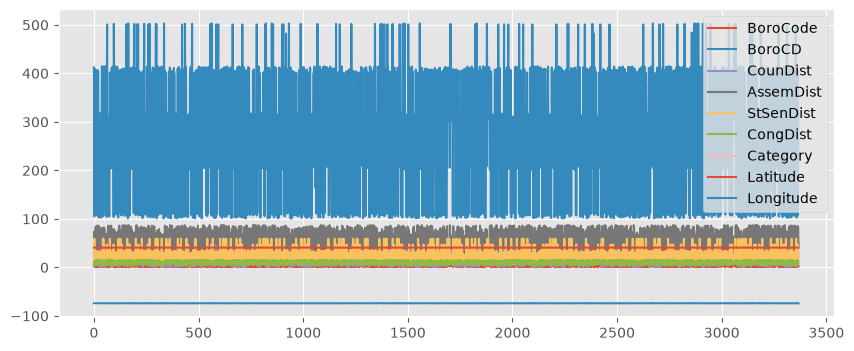

In [46]:
df.plot()  # useless data

<Axes: xlabel='Asset_Subtype'>

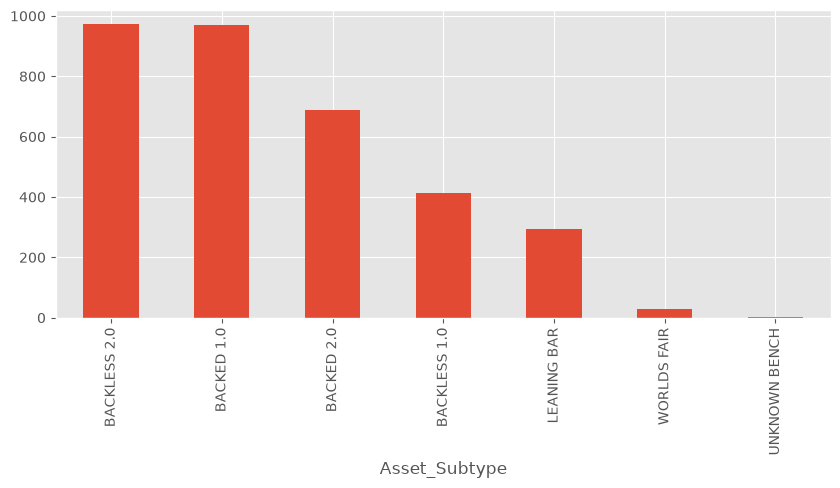

In [47]:
df_design = df["Asset_Subtype"].value_counts()
df_design.plot(kind="bar")

<Axes: >

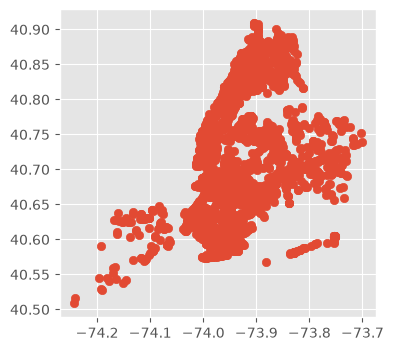

In [48]:
gdf.plot()  # this already shows the nyc map

### geometry/mapping analysis


In [49]:
df["geometry"] = df["the_geom"].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

In [50]:
gdf["longitude"] = gdf.geometry.x
gdf["latitude"] = gdf.geometry.y

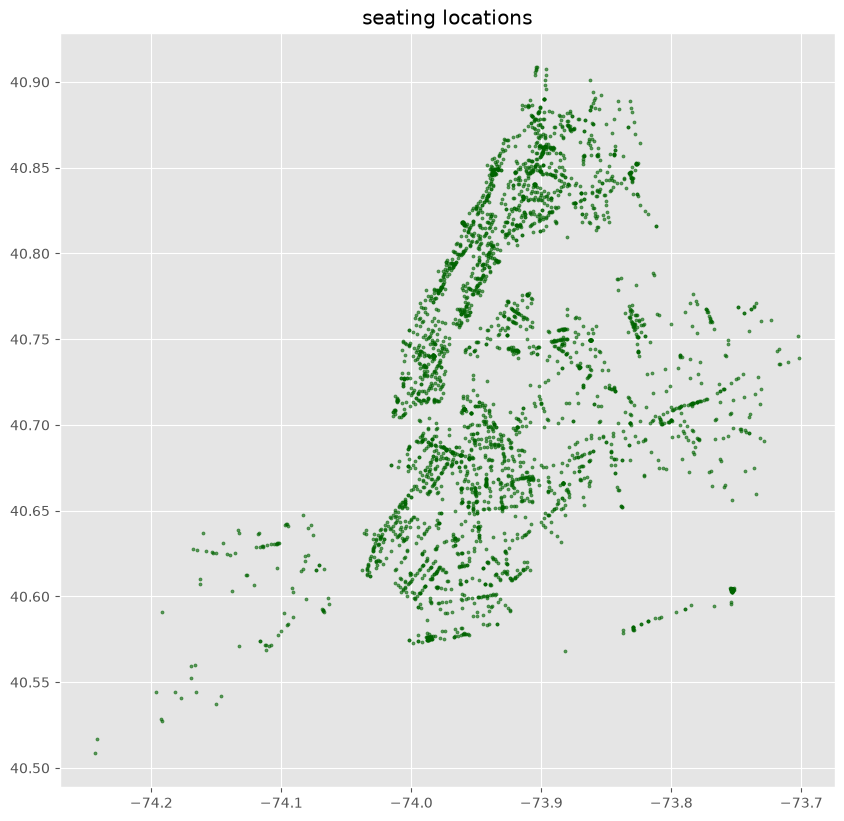

In [51]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, markersize=5, color="darkgreen", alpha=0.6)
ax.set_title("seating locations")
plt.show()

In [52]:
seating_data = gpd.read_file("./Data/Seating_Locations_20260319.csv")

In [53]:
seating_data.head()

,the_geom,BoroCode,BoroName,BoroCD,CounDist,AssemDist,StSenDist,CongDist,Category,Nearest_Add,...,Installation Date,Asset_ID,Asset_Subtype,Latitude,Longitude,SiteID,NTAName,FEMAFldz,FEMAFldT,HrcEvac
0,POINT (-73.77764762515179 40.714010735199224),4,Queens,412,23,29,11,5,,184-06 Hillside Avenue,...,09/25/2025,Color: Black (),BACKLESS 2.0,40.714019,-73.777649,SEAT.2025.0602,Jamaica,X,AREA OF MINIMAL FLOOD HAZARD,X
1,POINT (-73.97171956435525 40.68020474857601),3,Brooklyn,308,35,44,25,10,,549 Bergen Street,...,08/16/2023,Color: Black (BL2-2023-1803),BACKLESS 2.0,40.680213,-73.971721,SEAT.2023.0699,Prospect Heights,X,AREA OF MINIMAL FLOOD HAZARD,X
2,POINT (-73.98617714651992 40.74000423163591),1,Manhattan,105,2,74,59,12,,100 E 23rd Street,...,12/04/2013,Color: Silver (BB1-2013-1108),BACKED 1.0,40.74001249,-73.98617859,SEAT.2013.0511,Gramercy,X,AREA OF MINIMAL FLOOD HAZARD,6
3,POINT (-73.93507363564494 40.84643419697625),1,Manhattan,112,10,72,31,13,,586 W 177th Street,...,12/04/2014,Color: Silver (BB1-2014-1839),BACKED 1.0,40.84644248,-73.93507507,SEAT.2014.0364,Washington Heights (South),X,AREA OF MINIMAL FLOOD HAZARD,X
4,POINT (-73.92876457432111 40.65217538214825),3,Brooklyn,317,41,58,20,9,,5149 Church Avenue,...,07/18/2012,Color: Silver (BL1-2012-0148),BACKLESS 1.0,40.65218363,-73.928766,SEAT.2012.0083,East Flatbush-Rugby,X,AREA OF MINIMAL FLOOD HAZARD,6


In [54]:
census_data = gpd.read_file("./Data/census_nyc_sp.fgb")

In [55]:
print(gdf.crs)
print(census_data.crs)

EPSG:4326
EPSG:2263


In [56]:
census_data = census_data.to_crs(gdf.crs)

In [57]:
seating_census = gpd.sjoin(gdf, census_data, how="left", predicate="within")

In [58]:
seating_count_by_type = (
    seating_census.groupby(["GISJOIN", "Asset_Subtype"]).size().unstack(fill_value=0)
)

seating_count_by_bg = (
    seating_census.groupby("GISJOIN").size().reset_index(name="seating_count")
)

In [59]:
if "seating_count" in census_data.columns:
    census_data = census_data.drop(columns=["seating_count"])

census_data = census_data.merge(seating_count_by_bg, on="GISJOIN", how="left")
census_data["seating_count"] = census_data["seating_count"].fillna(0)

<Axes: >

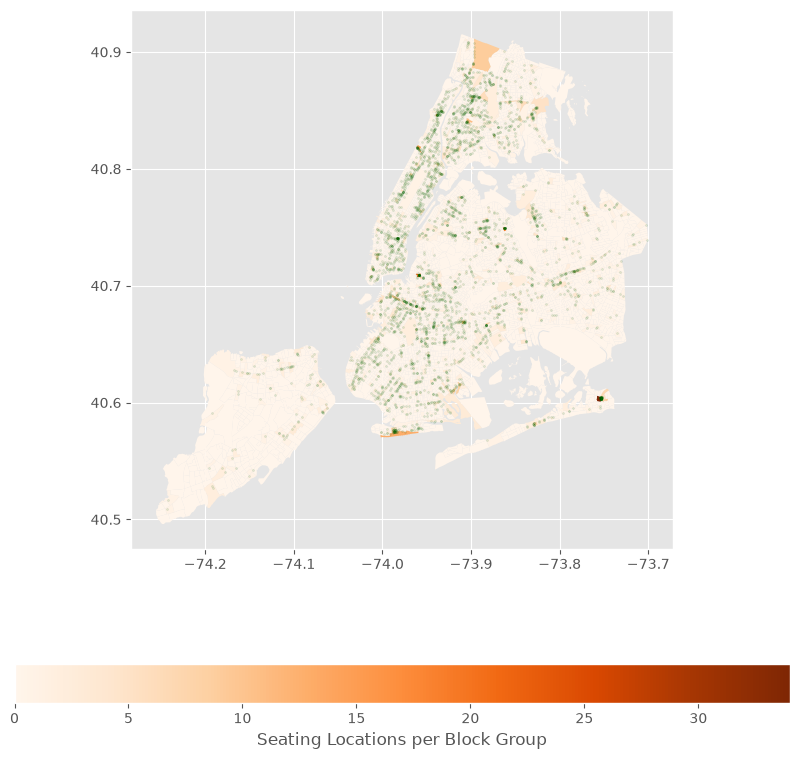

In [60]:
ax = census_data.plot(
    column="seating_count",
    legend=True,
    figsize=(10, 10),
    cmap="Oranges",
    legend_kwds={
        "label": "Seating Locations per Block Group",
        "orientation": "horizontal",
    },
)
gdf.plot(ax=ax, markersize=2, color="darkgreen", alpha=0.1)

In [61]:
print(seating_census["index_right"].isna().sum(), "/", len(seating_census))
print(census_data["seating_count"].describe())
print(census_data["seating_count"].value_counts().head(10))

0 / 3368
count    6593.000000
mean        0.510845
std         1.191945
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        34.000000
Name: seating_count, dtype: float64
seating_count
0.0     4604
1.0     1280
2.0      444
3.0      127
4.0       62
5.0       30
6.0       15
7.0       11
8.0        6
11.0       3
Name: count, dtype: int64


In [62]:
print(census_data.geometry.name)
print(census_data.geom_type.value_counts())

geometry
MultiPolygon    6593
Name: count, dtype: int64


<Axes: >

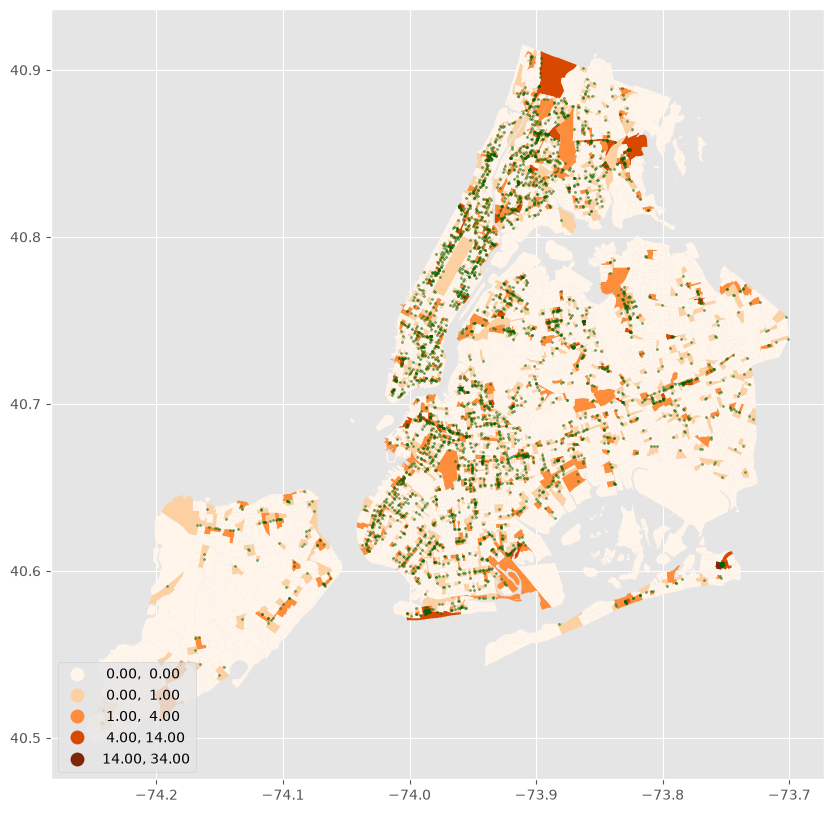

In [63]:
ax = census_data.plot(
    column="seating_count",
    legend=True,
    figsize=(10, 10),
    cmap="Oranges",
    scheme="natural_breaks",
    k=5,
    legend_kwds={"loc": "lower left"},
)
gdf.plot(ax=ax, markersize=2, color="darkgreen", alpha=0.5)

In [64]:
chinatown_gdf = gpd.read_file("./Data/chinatown.geojson")
print(chinatown_gdf.geom_type)
print(chinatown_gdf.crs)

0    LineString
dtype: str
EPSG:4326


In [65]:
from shapely.geometry import Polygon, MultiPolygon

In [66]:
chinatown_gdf["geometry"] = chinatown_gdf["geometry"].apply(
    lambda geom: Polygon(geom.coords)
)

0    Polygon
dtype: str


<Axes: >

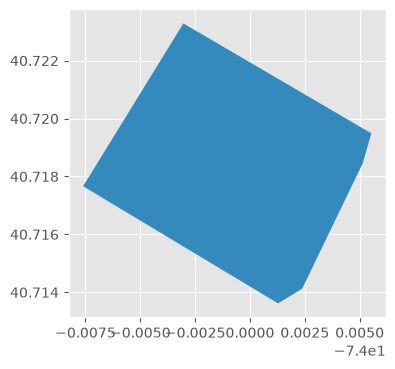

In [67]:
print(chinatown_gdf.geom_type)
chinatown_gdf.plot()

In [68]:
seating_chinatown = gpd.clip(gdf, chinatown_gdf)
census_chinatown = gpd.clip(census_data, chinatown_gdf)

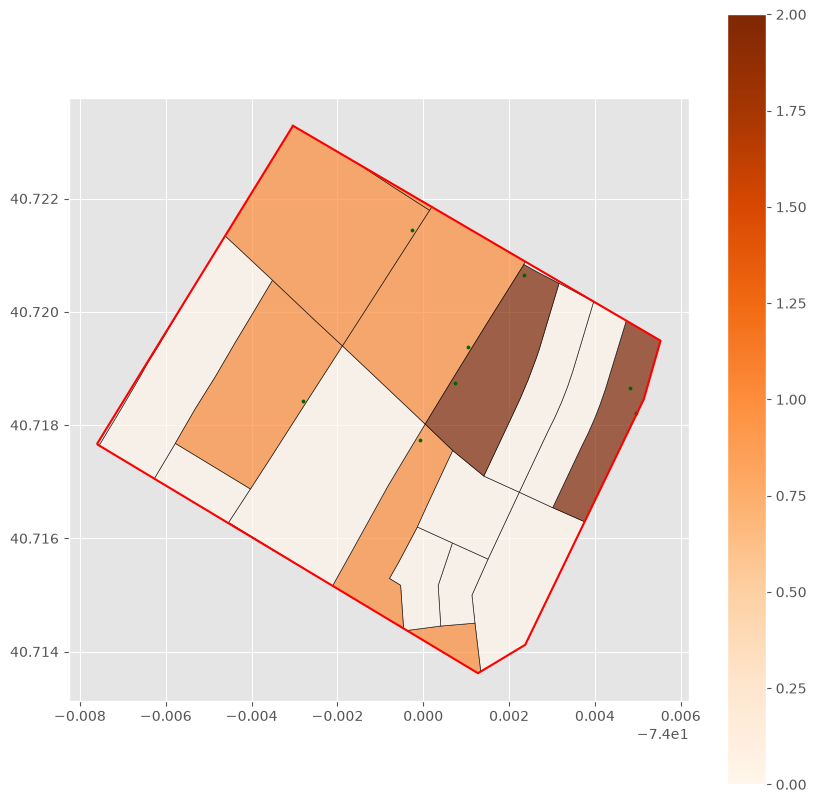

In [69]:
fig, ax = plt.subplots(figsize=(10, 10))
chinatown_gdf.boundary.plot(ax=ax, color="red", linewidth=1.5)
census_chinatown.plot(
    ax=ax,
    column="seating_count",
    cmap="Oranges",
    edgecolor="black",
    legend=True,
    alpha=0.7,
)
seating_chinatown.plot(ax=ax, color="darkgreen", markersize=5)
plt.show()

In [70]:
print(census_data.columns.tolist())

['GISJOIN', 'Total Pop (Race/Ethnicity)', 'Not Hispanic or Latino', 'Not Hispanic or Latino: White alone', 'Not Hispanic or Latino: Black or African American alone', 'Not Hispanic or Latino: American Indian and Alaska Native alone', 'Not Hispanic or Latino: Asian alone', 'Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone', 'Not Hispanic or Latino: Some other race alone', 'Not Hispanic or Latino: Two or more races', 'Not Hispanic or Latino: Two or more races: Two races including Some other race', 'Not Hispanic or Latino: Two or more races: Two races excluding Some other race, and three or more races', 'Hispanic or Latino', 'Total Households (Income)', 'Less than $10,000', '$10,000 to $14,999', '$15,000 to $19,999', '$20,000 to $24,999', '$25,000 to $29,999', '$30,000 to $34,999', '$35,000 to $39,999', '$40,000 to $44,999', '$45,000 to $49,999', '$50,000 to $59,999', '$60,000 to $74,999', '$75,000 to $99,999', '$100,000 to $124,999', '$125,000 to $149,999', '$150,0

In [71]:
census_block_df = pd.read_csv("./Data/2020_Census_Blocks_20260715.csv")
print(census_block_df.columns.tolist())

['the_geom', 'CB2020', 'BoroCode', 'BoroName', 'CT2020', 'BCTCB2020', 'GEOID', 'Shape_Length', 'Shape_Area']


In [72]:
census_block_df["the_geom"] = census_block_df["the_geom"].apply(wkt.loads)

census_block_gdf = gpd.GeoDataFrame(
    census_block_df, geometry="the_geom", crs="EPSG:4326"
)

census_block_gdf = census_block_gdf.to_crs(gdf.crs)

EPSG:4326
MultiPolygon    37588
Name: count, dtype: int64


<Axes: >

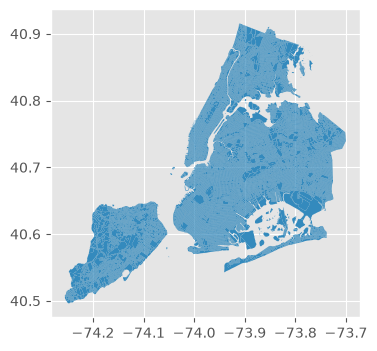

In [73]:
print(census_block_gdf.crs)
print(census_block_gdf.geom_type.value_counts())
census_block_gdf.plot()

In [74]:
census_block_chinatown = gpd.clip(census_block_gdf, chinatown_gdf)

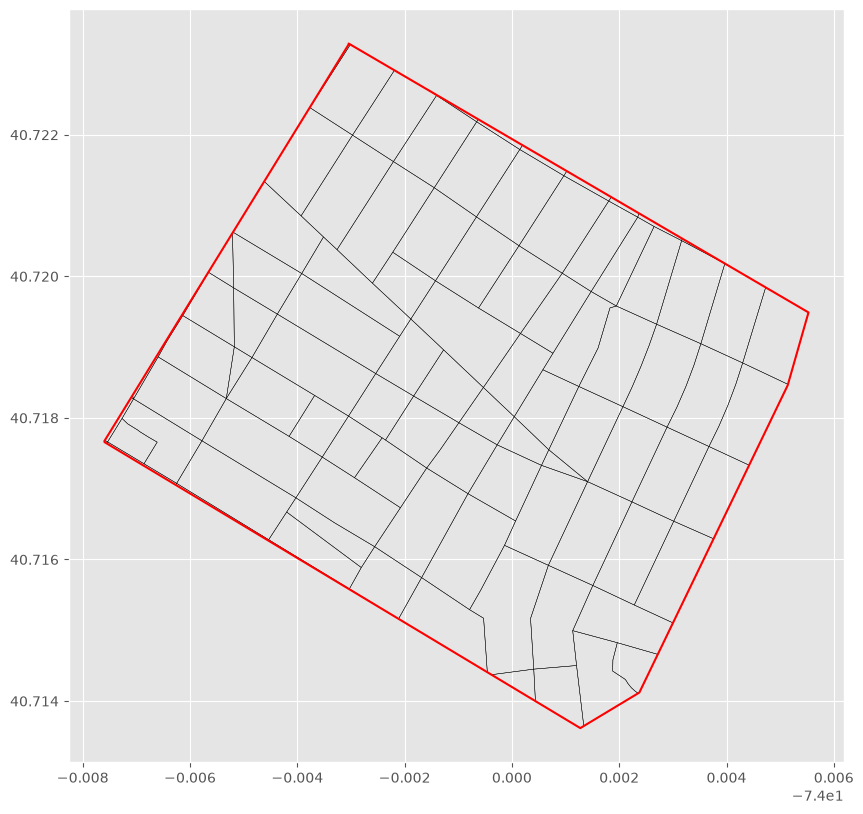

In [75]:
fig, ax = plt.subplots(figsize=(10, 10))
census_block_chinatown.plot(ax=ax, edgecolor="black", linewidth=0.3, facecolor="none")
chinatown_gdf.boundary.plot(ax=ax, color="red", linewidth=1.5)
plt.show()

In [76]:
print(census_block_chinatown.columns.tolist())

['the_geom', 'CB2020', 'BoroCode', 'BoroName', 'CT2020', 'BCTCB2020', 'GEOID', 'Shape_Length', 'Shape_Area']


In [77]:
seating_with_block = gpd.sjoin(
    seating_chinatown, census_block_chinatown, how="left", predicate="within"
)

seating_count_by_block = (
    seating_with_block.groupby("GEOID").size().reset_index(name="seating_count")
)

census_block_chinatown = census_block_chinatown.merge(
    seating_count_by_block, on="GEOID", how="left"
)
census_block_chinatown["seating_count"] = census_block_chinatown[
    "seating_count"
].fillna(0)

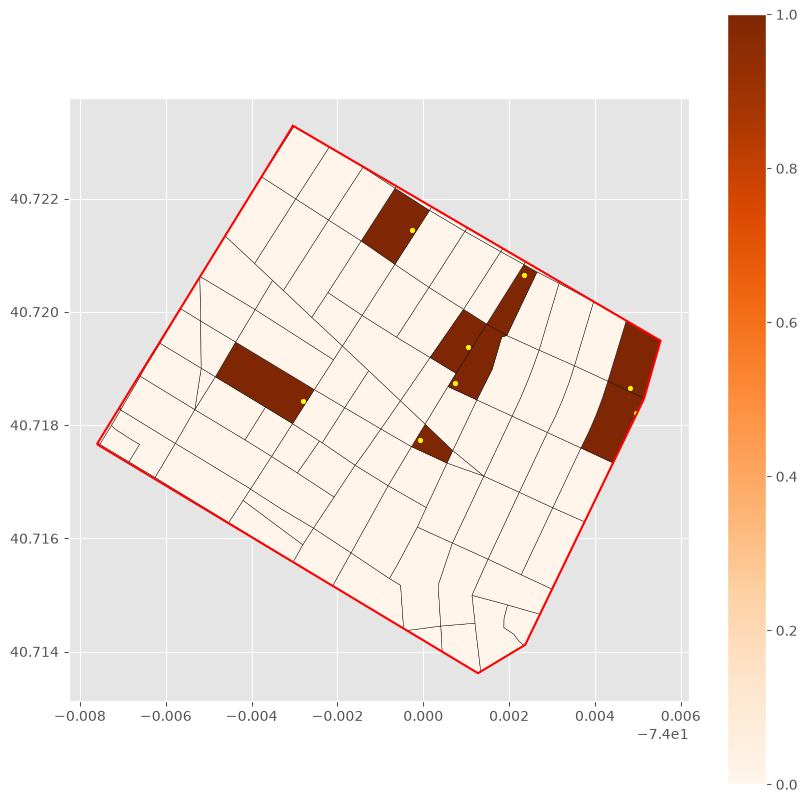

In [78]:
ax = census_block_chinatown.plot(
    column="seating_count",
    cmap="Oranges",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3,
)
chinatown_gdf.boundary.plot(ax=ax, color="red", linewidth=1.5)
seating_chinatown.plot(ax=ax, color="yellow", markersize=10)
plt.show()

In [79]:
census_block_chinatown["seating_count"].value_counts().head(10)

seating_count
0.0    93
1.0     8
Name: count, dtype: int64

In [80]:
# refer to meli's json for sidewalk widths

sidewalk_bounds = chinatown_gdf.total_bounds  # [minx, miny, maxx, maxy]

sidewalk_gdf = gpd.read_file(
    "https://raw.githubusercontent.com/meliharvey/sidewalkwidths-nyc/master/sidewalkwidths_nyc.geojson",
    bbox=tuple(sidewalk_bounds),
)

In [81]:
print(sidewalk_gdf.crs)

EPSG:4326


In [82]:
sidewalk_chinatown = gpd.clip(sidewalk_gdf, chinatown_gdf)

In [83]:
sidewalk_with_block = gpd.sjoin(
    sidewalk_chinatown, census_block_chinatown, how="left", predicate="intersects"
)

In [84]:
width_by_block = (
    sidewalk_with_block.groupby("GEOID")["width"]
    .agg(mean_width="mean", median_width="median", n_segments="count")
    .reset_index()
)

In [85]:
census_block_chinatown = census_block_chinatown.merge(
    width_by_block, on="GEOID", how="left"
)

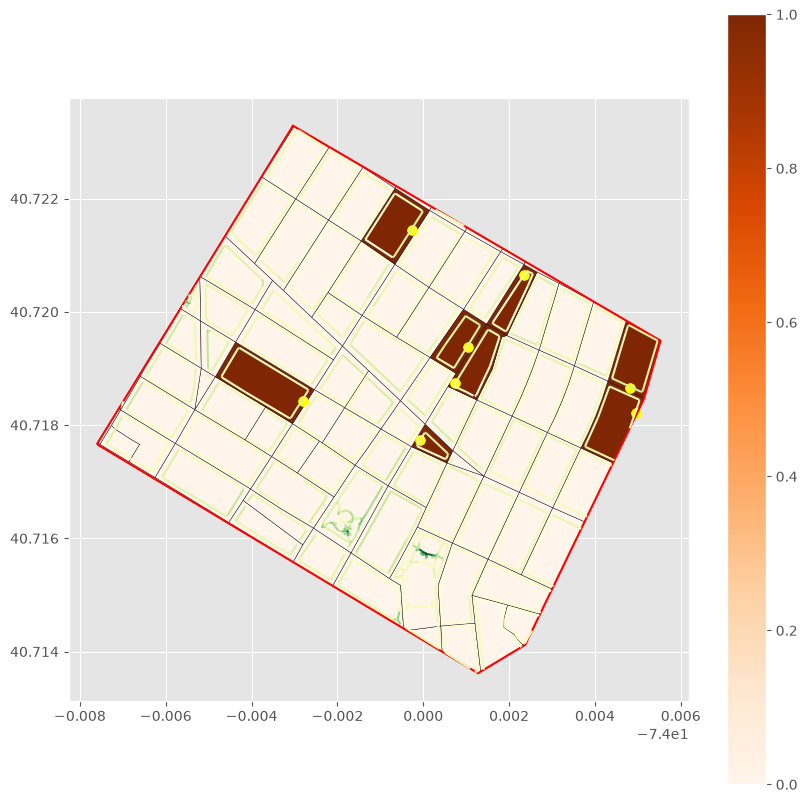

In [86]:
ax = census_block_chinatown.plot(
    column="seating_count",
    cmap="Oranges",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3,
)
chinatown_gdf.boundary.plot(ax=ax, color="red", linewidth=1.5)
sidewalk_chinatown.plot(ax=ax, column="width", cmap="YlGn", linewidth=1.5)
seating_chinatown.plot(ax=ax, color="yellow", markersize=50)
plt.show()

In [87]:
seating_chinatown["Installation Date"] = pd.to_datetime(
    seating_chinatown["Installation Date"]
)

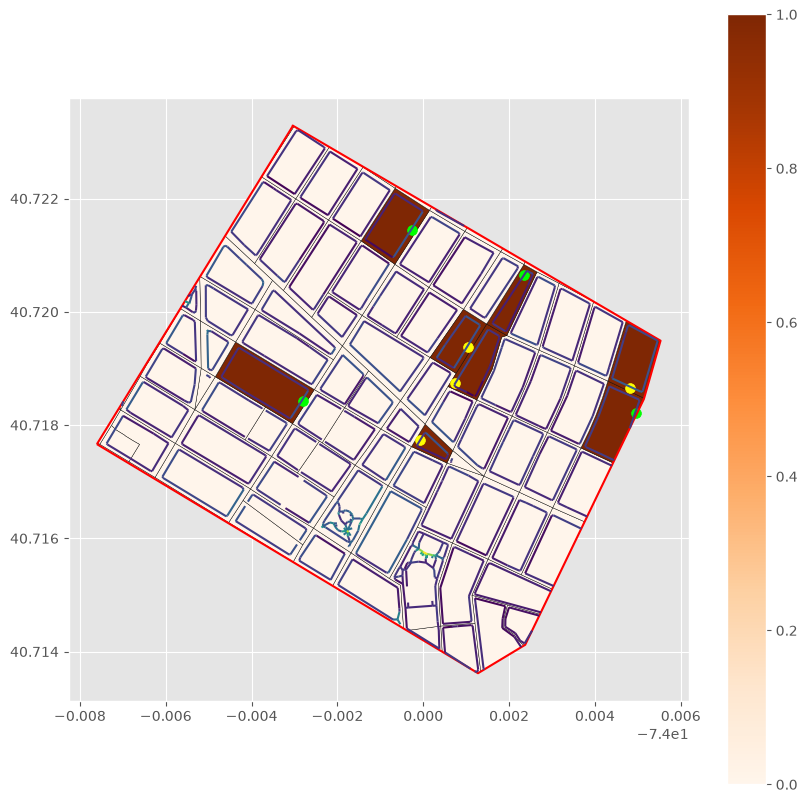

In [88]:
ax = census_block_chinatown.plot(
    column="seating_count",
    cmap="Oranges",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.3,
)
chinatown_gdf.boundary.plot(ax=ax, color="red", linewidth=1.5)
sidewalk_chinatown.plot(ax=ax, column="width", cmap="viridis", linewidth=1.5)
seating_chinatown_past = seating_chinatown[
    seating_chinatown["Installation Date"] < "2020-01-01"
]
seating_chinatown_after = seating_chinatown[
    seating_chinatown["Installation Date"] >= "2020-01-01"
]
seating_chinatown_past.plot(ax=ax, color="yellow", markersize=50)
seating_chinatown_after.plot(ax=ax, color="lime", markersize=50)
plt.show()

In [89]:
print(seating_chinatown.columns.tolist())

['the_geom', 'BoroCode', 'BoroName', 'BoroCD', 'CounDist', 'AssemDist', 'StSenDist', 'CongDist', 'Category', 'Nearest_Add', 'On_Street', 'From_Street', 'To_Street', 'Side_of_St', 'Installation Date', 'Asset_ID', 'Asset_Subtype', 'Latitude', 'Longitude', 'SiteID', 'NTAName', 'FEMAFldz', 'FEMAFldT', 'HrcEvac', 'geometry', 'longitude', 'latitude']


In [90]:
print(seating_chinatown.geometry)

356     POINT (-73.99505 40.71822)
395     POINT (-74.00007 40.71774)
2848    POINT (-74.00281 40.71843)
2801    POINT (-73.99926 40.71875)
3317    POINT (-73.99895 40.71938)
1220    POINT (-73.99765 40.72066)
1546    POINT (-73.99518 40.71866)
1552    POINT (-74.00027 40.72144)
Name: geometry, dtype: geometry


In [91]:
print(seating_chinatown["Installation Date"])

356    2026-01-12
395    2017-08-04
2848   2025-05-31
2801   2017-08-04
3317   2015-06-05
1220   2025-08-18
1546   2016-06-02
1552   2025-05-10
Name: Installation Date, dtype: datetime64[us]


In [92]:
seating_chinatown[["geometry", "Installation Date"]].sort_values(by="Installation Date")

,geometry,Installation Date
3317,POINT (-73.99895 40.71938),2015-06-05
1546,POINT (-73.99518 40.71866),2016-06-02
395,POINT (-74.00007 40.71774),2017-08-04
2801,POINT (-73.99926 40.71875),2017-08-04
1552,POINT (-74.00027 40.72144),2025-05-10
2848,POINT (-74.00281 40.71843),2025-05-31
1220,POINT (-73.99765 40.72066),2025-08-18
356,POINT (-73.99505 40.71822),2026-01-12


In [93]:
seating_chinatown[["geometry", "Installation Date"]].sort_values(by="Installation Date")

,geometry,Installation Date
3317,POINT (-73.99895 40.71938),2015-06-05
1546,POINT (-73.99518 40.71866),2016-06-02
395,POINT (-74.00007 40.71774),2017-08-04
2801,POINT (-73.99926 40.71875),2017-08-04
1552,POINT (-74.00027 40.72144),2025-05-10
2848,POINT (-74.00281 40.71843),2025-05-31
1220,POINT (-73.99765 40.72066),2025-08-18
356,POINT (-73.99505 40.71822),2026-01-12


In [97]:
%pip install osmnx

  Using cached osmnx-2.1.0-py3-none-any.whl.metadata (4.7 kB)
Using cached osmnx-2.1.0-py3-none-any.whl (104 kB)

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [99]:
import osmnx as ox
import networkx as nx

In [112]:
block_bbox = census_block_chinatown.to_crs(
    epsg=4326
).total_bounds  # [minx, miny, maxx, maxy]

G = ox.graph_from_bbox(bbox=block_bbox, network_type="walk")
G_proj = ox.project_graph(G, to_crs="EPSG:2263")

In [113]:
seating_proj = seating_chinatown.to_crs(epsg=2263).reset_index(drop=True)

seating_proj["node"] = ox.distance.nearest_nodes(
    G_proj,
    X=seating_proj.geometry.x,
    Y=seating_proj.geometry.y,
)

In [114]:
def network_distance_between_points(node1, node2, G_proj):
    try:
        route = ox.shortest_path(G_proj, node1, node2, weight="length")
        if route is None:
            return np.nan, None
        edge_lengths = ox.routing.route_to_gdf(G_proj, route)["length"]
        route_geom = ox.routing.route_to_gdf(G_proj, route).geometry.union_all()
        return sum(edge_lengths), route_geom
    except (nx.NetworkXNoPath, ValueError):
        return np.nan, None

In [115]:
from itertools import combinations

results = []
for i, j in combinations(seating_proj.index, 2):
    node1 = seating_proj.loc[i, "node"]
    node2 = seating_proj.loc[j, "node"]
    dist_ft, route_geom = network_distance_between_points(node1, node2, G_proj)
    results.append(
        {
            "point_1": i,
            "point_2": j,
            "distance_ft": dist_ft,
            "route_geom": route_geom,
        }
    )

seating_distances = pd.DataFrame(results)

In [116]:
seating_distances.sort_values("distance_ft")

,point_1,point_2,distance_ft,route_geom
5,0,6,17.231317,LINESTRING (985642.3408354664 201025.084635152...
8,1,3,137.982971,MULTILINESTRING ((984210.1375676077 200732.377...
18,3,4,144.887173,MULTILINESTRING ((984446.8141702687 201117.876...
22,4,5,155.784729,MULTILINESTRING ((984620.6977030297 201507.275...
7,1,2,249.803662,MULTILINESTRING ((984210.1375676077 200732.377...
24,4,7,267.434213,MULTILINESTRING ((984620.6977030297 201507.275...
19,3,5,267.537011,MULTILINESTRING ((984446.8141702687 201117.876...
9,1,4,280.983577,MULTILINESTRING ((984210.1375676077 200732.377...
26,5,7,334.244334,MULTILINESTRING ((984919.7022005161 201856.966...
3,0,4,345.969300,MULTILINESTRING ((985642.3408354664 201025.084...


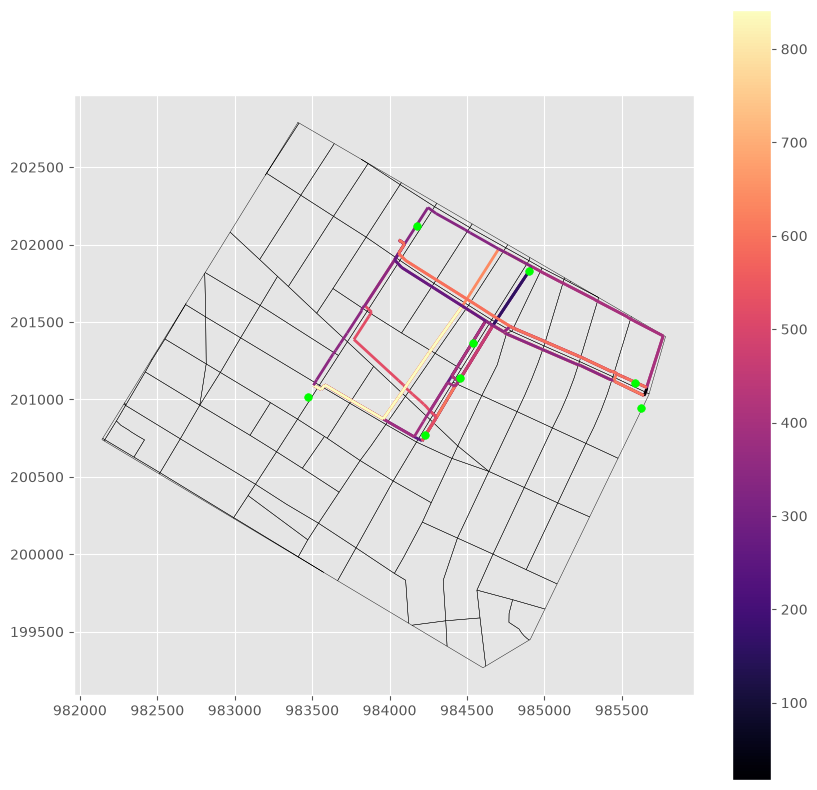

In [118]:
routes_gdf = gpd.GeoDataFrame(
    seating_distances.dropna(subset=["route_geom"]),
    geometry="route_geom",
    crs="EPSG:2263",
)

fig, ax = plt.subplots(figsize=(10, 10))
census_block_chinatown.to_crs(epsg=2263).plot(
    ax=ax, facecolor="none", edgecolor="black", linewidth=0.3
)
routes_gdf.plot(column="distance_ft", cmap="magma", ax=ax, linewidth=2, legend=True)
seating_proj.plot(ax=ax, color="lime", markersize=30, zorder=5)
plt.show()

In [119]:
closest_pair = seating_distances.loc[seating_distances["distance_ft"].idxmin()]
farthest_pair = seating_distances.loc[seating_distances["distance_ft"].idxmax()]

print(closest_pair)
print(farthest_pair)

point_1                                                        0
point_2                                                        6
distance_ft                                            17.231317
route_geom     LINESTRING (985642.3408354664 201025.084635152...
Name: 5, dtype: object
point_1                                                        2
point_2                                                        6
distance_ft                                           841.708739
route_geom     MULTILINESTRING ((983508.2869688539 201091.291...
Name: 16, dtype: object


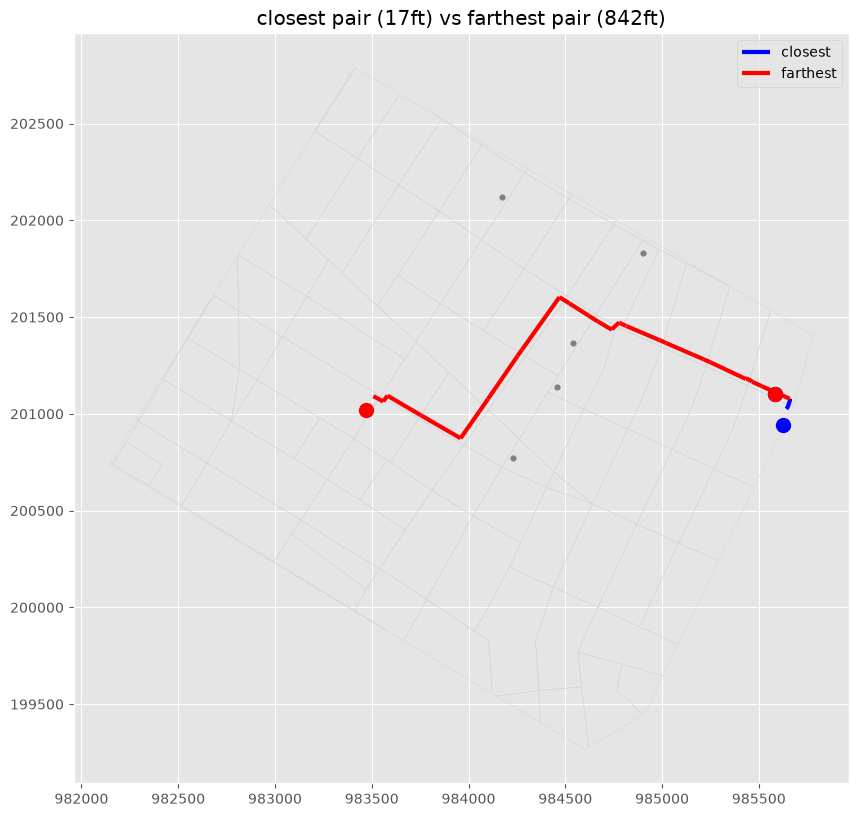

In [120]:
highlight = pd.concat(
    [
        pd.DataFrame([closest_pair]).assign(type="closest"),
        pd.DataFrame([farthest_pair]).assign(type="farthest"),
    ]
)

highlight_gdf = gpd.GeoDataFrame(highlight, geometry="route_geom", crs="EPSG:2263")

fig, ax = plt.subplots(figsize=(10, 10))
census_block_chinatown.to_crs(epsg=2263).plot(
    ax=ax, facecolor="none", edgecolor="lightgrey", linewidth=0.3
)
seating_proj.plot(ax=ax, color="grey", markersize=15, zorder=3)

colors = {"closest": "blue", "farthest": "red"}
for t, group in highlight_gdf.groupby("type"):
    group.plot(ax=ax, color=colors[t], linewidth=3, label=t, zorder=4)

for _, row in highlight.iterrows():
    for pid in [row["point_1"], row["point_2"]]:
        pt = seating_proj.loc[pid, "geometry"]
        ax.plot(pt.x, pt.y, "o", color=colors[row["type"]], markersize=10, zorder=5)

ax.legend()
ax.set_title(
    f"closest pair ({closest_pair['distance_ft']:.0f}ft) vs farthest pair ({farthest_pair['distance_ft']:.0f}ft)"
)
plt.show()